# Task 1: Build a Random Forest Classifier

## Objective

The goal of this project is to build a Random Forest classification model using the Forest CoverType dataset.

The model will:

1. Load a complex real-world classification dataset.
2. Explore the dataset.
3. Train a Random Forest Classifier.
4. Evaluate the model using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion matrix
   - Cross-validation
5. Tune hyperparameters.
6. Analyze feature importance.
7. Save the final trained model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

## Load Dataset

We use the Forest CoverType dataset from scikit-learn.

This is a multiclass classification dataset where the target variable represents forest cover type.

In [3]:
from sklearn.datasets import fetch_covtype

data = fetch_covtype(as_frame=True)

X = data.data
y = data.target

print(X.shape)
print(y.value_counts().sort_index())

(581012, 54)
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


In [4]:
# Inspect the dataset
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Show basic information about the dataset
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1                   5

In [6]:
# Describe the dataset
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [ ]:
# Target summary
target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
Cover_Type,,
1,211840,36.46
2,283301,48.76
3,35754,6.15
4,2747,0.47
5,9493,1.63
6,17367,2.99
7,20510,3.53


## Missing Value Check

Before training, I have to check whether the dataset contains missing values.
Random Forest can handle complex feature relationships, but missing values should still be checked before modeling.

In [9]:
missing_values = X.isnull().sum()

missing_values[missing_values > 0]

print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


No missing values in the dataset

In [12]:
USE_SAMPLE = False
SAMPLE_SIZE = 100_000

if USE_SAMPLE:
    X_model, _, y_model, _ = train_test_split(
        X,
        y,
        train_size=SAMPLE_SIZE,
        stratify=y,
        random_state=42
    )
else:
    X_model = X
    y_model = y

print("Modeling dataset shape:", X_model.shape)
print(y_model.value_counts().sort_index())

Modeling dataset shape: (581012, 54)
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


## Train-Test Split

We split the data into:

- 80% training data
- 20% testing data

Because this is a multiclass classification problem, I will use stratified splitting to preserve the class distribution.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    stratify=y_model,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (464809, 54)
X_test: (116203, 54)
y_train: (464809,)
y_test: (116203,)


## Baseline Model

Before training a Random Forest, we create a simple baseline.

The baseline accuracy is the accuracy we would get if we always predicted the most common class.

Our Random Forest model should perform much better than this.

In [15]:
baseline_accuracy = y_train.value_counts(normalize=True).max()

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline accuracy: 0.4876


## Initial Random Forest Model

We now train a Random Forest Classifier.

Important parameters:

- `n_estimators`: number of trees
- `max_depth`: maximum tree depth
- `max_features`: number of features considered at each split
- `class_weight`: helps when classes are imbalanced
- `n_jobs=-1`: uses all available CPU cores

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [17]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

print(y_pred[:20])

[1 3 2 3 1 3 1 1 2 2 1 1 1 2 2 2 1 1 3 2]


## Model Evaluation

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-score

Since this is a multiclass classification problem, I will calculate both macro and weighted scores.

Macro average treats all classes equally.

Weighted average accounts for class imbalance.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1 Weighted"
    ],
    "Score": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

results

,Metric,Score
0,Accuracy,0.955328
1,Precision Macro,0.944882
2,Recall Macro,0.907342
3,F1 Macro,0.924828
4,Precision Weighted,0.955470
5,Recall Weighted,0.955328
6,F1 Weighted,0.955122


In [19]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           1     0.9670    0.9432    0.9550     42368
           2     0.9501    0.9748    0.9623     56661
           3     0.9365    0.9608    0.9485      7151
           4     0.9077    0.8415    0.8733       549
           5     0.9449    0.7946    0.8633      1899
           6     0.9353    0.8868    0.9104      3473
           7     0.9728    0.9495    0.9610      4102

    accuracy                         0.9553    116203
   macro avg     0.9449    0.9073    0.9248    116203
weighted avg     0.9555    0.9553    0.9551    116203



## Confusion Matrix

A confusion matrix helps me see which classes the model predicts correctly and which classes it confuses.

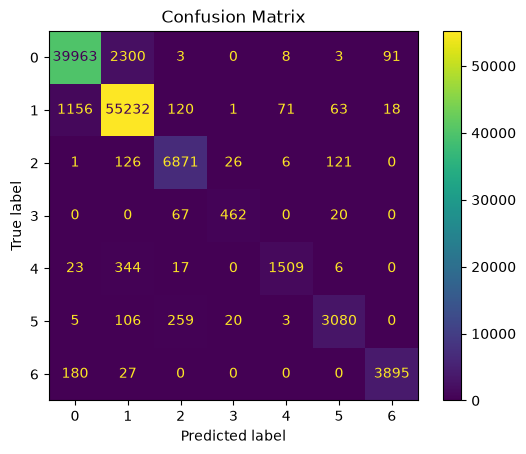

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

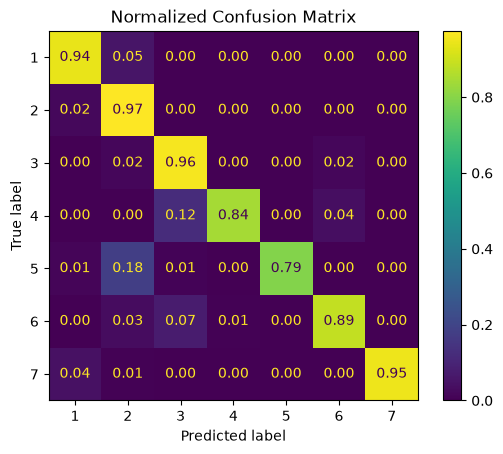

In [21]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.show()

## Cross-Validation

Instead of relying only on one train-test split, we use cross-validation.

This gives a more stable estimate of model performance.

In [22]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame(cv_results).agg(["mean", "std"]).T
cv_summary

ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 163, in _parallel_build_trees
    tree._fit(
    ~~~~~~~~~^
        X,
        ^^
    ...<3 lines>...
        missing_values_in_feature_mask=missing_values_in_feature_mask,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\tree\_classes.py", line 467, in _fit
    builder.build(self.tree_, X, y, sample_weight, missing_values_in_feature_mask)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "sklearn/tree/_tree.pyx", line 139, in sklearn.tree._tree.DepthFirstTreeBuilder.build
  File "sklearn/tree/_tree.pyx", line 254, in sklearn.tree._tree.DepthFirstTreeBuilder.build
    node_id = tree._add_node(parent, is_left, is_leaf, split.feature,
  File "sklearn/tree/_tree.pyx", line 909, in sklearn.tree._tree.Tree._add_node
    if self._resize_c() != 0:
  File "sklearn/tree/_tree.pyx", line 877, in sklearn.tree._tree.Tree._resize_c
    safe_realloc(&self.nodes, capacity)
  File "sklearn/tree/_utils.pyx", line 28, in sklearn.tree._utils.safe_realloc
MemoryError: could not allocate 4194304 bytes
"""

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 468, in fit
    trees = Parallel(
    ...<2 lines>...
        prefer="threads",
    )(
        delayed(_parallel_build_trees)(
    ...<12 lines>...
        for i, t in enumerate(trees)
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 91, in __call__
    return super().__call__(iterable_with_config_and_warning_filters)
           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
                                                ~~~~^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1784, in _retrieve
    self._raise_error_fast()
    ~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1859, in _raise_error_fast
    error_job.get_result(self.timeout)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 758, in get_result
    return self._return_or_raise()
           ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 773, in _return_or_raise
    raise self._result
MemoryError: could not allocate 4194304 bytes

--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 158, in _parallel_build_trees
    expanded_class_weight = compute_sample_weight(
        "balanced", y, indices=indices
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_param_validation.py", line 191, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\class_weight.py", line 240, in compute_sample_weight
    weight_k = weight_k[np.searchsorted(classes_full, y_full)]
               ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 2.36 MiB for an array with shape (309873,) and data type float64
"""

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 468, in fit
    trees = Parallel(
    ...<2 lines>...
        prefer="threads",
    )(
        delayed(_parallel_build_trees)(
    ...<12 lines>...
        for i, t in enumerate(trees)
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 91, in __call__
    return super().__call__(iterable_with_config_and_warning_filters)
           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
                                                ~~~~^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1784, in _retrieve
    self._raise_error_fast()
    ~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1859, in _raise_error_fast
    error_job.get_result(self.timeout)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 758, in get_result
    return self._return_or_raise()
           ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 773, in _return_or_raise
    raise self._result
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 2.36 MiB for an array with shape (309873,) and data type float64

--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 158, in _parallel_build_trees
    expanded_class_weight = compute_sample_weight(
        "balanced", y, indices=indices
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_param_validation.py", line 191, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\class_weight.py", line 227, in compute_sample_weight
    compute_class_weight(
    ~~~~~~~~~~~~~~~~~~~~^
        class_weight_k, classes=classes_subsample, y=y_subsample
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ),
    ^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_param_validation.py", line 191, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\class_weight.py", line 87, in compute_class_weight
    y_ind = le.fit_transform(y)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py", line 121, in fit_transform
    self.classes_, y = _unique(y, return_inverse=True)
                       ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_encode.py", line 50, in _unique
    return _unique_np(
        values, return_inverse=return_inverse, return_counts=return_counts
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_encode.py", line 65, in _unique_np
    uniques, inverse = xp.unique_inverse(values)
                       ~~~~~~~~~~~~~~~~~^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\externals\array_api_compat\_internal.py", line 35, in wrapped_f
    return f(*args, xp=xp, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\externals\array_api_compat\common\_aliases.py", line 241, in unique_inverse
    values, inverse_indices = xp.unique(
                              ~~~~~~~~~^
        x,
        ^^
    ...<3 lines>...
        **kwargs,
        ^^^^^^^^^
    )
    ^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_arraysetops_impl.py", line 296, in unique
    ret = _unique1d(ar, return_index, return_inverse, return_counts,
                    equal_nan=equal_nan, inverse_shape=ar.shape, axis=None,
                    sorted=sorted)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_arraysetops_impl.py", line 358, in _unique1d
    ar = np.asanyarray(ar).flatten()
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 2.36 MiB for an array with shape (309873,) and data type float64
"""

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py", line 468, in fit
    trees = Parallel(
    ...<2 lines>...
        prefer="threads",
    )(
        delayed(_parallel_build_trees)(
    ...<12 lines>...
        for i, t in enumerate(trees)
    )
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py", line 91, in __call__
    return super().__call__(iterable_with_config_and_warning_filters)
           ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 2072, in __call__
    return output if self.return_generator else list(output)
                                                ~~~~^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1682, in _get_outputs
    yield from self._retrieve()
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1784, in _retrieve
    self._raise_error_fast()
    ~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 1859, in _raise_error_fast
    error_job.get_result(self.timeout)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 758, in get_result
    return self._return_or_raise()
           ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Asus Gaming\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\parallel.py", line 773, in _return_or_raise
    raise self._result
numpy._core._exceptions._ArrayMemoryError: Unable to allocate 2.36 MiB for an array with shape (309873,) and data type float64
